# Notebook 01 — Exploratory Data Analysis (EDA)

---

| Field | Details |
|:---|:---|
| **Project** | UNet-Based Segmentation for Small Medical Datasets |
| **Dataset** | 2018 Kaggle Data Science Bowl — Nuclei Segmentation |
| **Notebook purpose** | Systematically explore dataset structure, statistics, and visual properties prior to any preprocessing or modelling step. All findings documented here directly motivate the design decisions implemented in Notebooks 02 & 03 (Preprocessing & Augmentation). |

---

## Table of Contents

1. [Setup and Imports](#1-setup-and-imports)
2. [Dataset Loading and Path Verification](#2-dataset-loading-and-path-verification)
3. [Folder and File Structure Inspection](#3-folder-and-file-structure-inspection)
4. [Global Dataset Statistics — Single-Pass Scan](#4-global-dataset-statistics--single-pass-scan)
5. [Image Size Distribution](#5-image-size-distribution)
6. [Channel Type Analysis](#6-channel-type-analysis)
7. [Pixel Intensity Analysis](#7-pixel-intensity-analysis)
8. [Nucleus Count Distribution](#8-nucleus-count-distribution)
9. [Mask Coverage and Class Imbalance](#9-mask-coverage-and-class-imbalance)
10. [Visual Sample Inspection](#10-visual-sample-inspection)
11. [Mask Quality and Validity Checks](#11-mask-quality-and-validity-checks)
12. [Train / Validation / Test Split Strategy](#12-train--validation--test-split-strategy)
13. [EDA Summary and Preprocessing Decisions](#13-eda-summary-and-preprocessing-decisions)

## 1. Setup and Imports

In [1]:
# Mount the Google Drive volume to provide persistent access to the dataset
# and output directories across Colab sessions.
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted successfully.')


Mounted at /content/drive
Google Drive mounted successfully.


In [2]:
import os
import random
import warnings
from collections import Counter
import numpy as np
import pandas as pd
from PIL import Image
import PIL
from scipy import stats
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')


# Matplotlib style — applied once for visual consistency across all figures.
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#f8f9fa',
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'grid.linestyle'    : '--',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'figure.dpi'        : 120,
})


# Global seed — ensures reproducible sampling and shuffling across all runs.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('All libraries imported successfully.')
print(f'  NumPy  : {np.__version__}')
print(f'  Pandas : {pd.__version__}')
# PIL.Image does not expose a __version__ attribute; the version string
# is available on the top-level PIL package object.
print(f'  Pillow : {PIL.__version__}')


All libraries imported successfully.
  NumPy  : 2.0.2
  Pandas : 2.2.2
  Pillow : 11.3.0


## 2. Dataset Loading and Path Verification

In [3]:
# Path constants and global configuration — edit these before running.

DRIVE_ROOT   = '/content/drive/MyDrive/Medical_Segmentation_Data/raw/stage1_train'
FIGURES_PATH = '/content/drive/MyDrive/Medical_Segmentation_Data/figures/'

# SPLITS_DIR is written by the split cell; created on first write only.
SPLITS_DIR   = '/content/drive/MyDrive/Medical_Segmentation_Data/splits'

# TARGET_SIZE: shared with preprocessing notebook for consistent plot labels.
TARGET_SIZE  = (256, 256)
_target_str  = f'{TARGET_SIZE[0]}x{TARGET_SIZE[1]}'

os.makedirs(FIGURES_PATH, exist_ok=True)

# Fail fast if the path is wrong — prevents silent downstream errors.
assert os.path.exists(DRIVE_ROOT), (
    f'Dataset path not found: {DRIVE_ROOT}\n'
    f'Verify the path or re-download the dataset from Kaggle.'
)

# Filter to directories only — excludes hidden files and metadata entries.
ALL_IDS = sorted([
    d for d in os.listdir(DRIVE_ROOT)
    if os.path.isdir(os.path.join(DRIVE_ROOT, d))
])

print('Dataset path verified.')
print(f'  Root path     : {DRIVE_ROOT}')
print(f'  Splits dir    : {SPLITS_DIR}')
print(f'  Target size   : {_target_str}')
print(f'  Total samples : {len(ALL_IDS)}')
print(f'  Example ID    : {ALL_IDS[0][:20]}...')


Dataset path verified.
  Root path     : /content/drive/MyDrive/Medical_Segmentation_Data/raw/stage1_train
  Splits dir    : /content/drive/MyDrive/Medical_Segmentation_Data/splits
  Target size   : 256x256
  Total samples : 670
  Example ID    : 00071198d059ba7f5914...


## 3. Folder and File Structure Inspection

Each sample directory follows a fixed two-level layout:

```
<sample_id>/
    images/   <-- exactly one PNG (the microscopy image)
    masks/    <-- N PNGs, one binary mask per nucleus instance
```


In [4]:
# Display the canonical two-level directory tree for the first sample as a
# representative illustration of the dataset layout.
sample_id   = ALL_IDS[0]
sample_path = os.path.join(DRIVE_ROOT, sample_id)

print('SINGLE SAMPLE DIRECTORY STRUCTURE')
print(f'  {sample_id[:16]}.../')

for subfolder in sorted(os.listdir(sample_path)):
    sub_path = os.path.join(sample_path, subfolder)

    if not os.path.isdir(sub_path):
        continue

    # Exclude hidden system files (e.g. .DS_Store on macOS-archived zips)
    # to report only actual data files in the count.
    files = [f for f in os.listdir(sub_path) if not f.startswith('.')]

    print(f'  |-- {subfolder}/  ({len(files)} file(s))')

    for f in sorted(files)[:2]:
        print(f'  |    |-- {f[:36]}...')

    if len(files) > 2:
        print(f'  |    |-- ... ({len(files)-2} additional files)')



# Structural integrity check — all samples
# Verifies that every sample has at least one PNG in its images/ directory
# and at least one PNG in its masks/ directory.  The check filters for .png
# files explicitly to avoid false positives from hidden system files
print(f'\nStructural integrity check (all {len(ALL_IDS)} samples)...')

missing_images = []
missing_masks  = []

for sid in tqdm(ALL_IDS, desc='Checking dataset structure'):

    img_dir  = os.path.join(DRIVE_ROOT, sid, 'images')
    mask_dir = os.path.join(DRIVE_ROOT, sid, 'masks')

    img_pngs  = [f for f in os.listdir(img_dir)  if f.endswith('.png')] if os.path.exists(img_dir)  else []
    mask_pngs = [f for f in os.listdir(mask_dir) if f.endswith('.png')] if os.path.exists(mask_dir) else []

    if not os.path.exists(img_dir) or len(img_pngs) == 0:
        missing_images.append(sid)

    if not os.path.exists(mask_dir) or len(mask_pngs) == 0:
        missing_masks.append(sid)

print('\nFINAL REPORT')
print(f'  Samples missing images : {len(missing_images)}')
print(f'  Samples missing masks  : {len(missing_masks)}')

if not missing_images and not missing_masks:
    print(f'  Result: All {len(ALL_IDS)} samples are structurally complete.')
else:
    print('  WARNING: Some samples have structural issues — review before training.')


SINGLE SAMPLE DIRECTORY STRUCTURE
  00071198d059ba7f.../
  |-- images/  (1 file(s))
  |    |-- 00071198d059ba7f5914a526d124d28e6d01...
  |-- masks/  (27 file(s))
  |    |-- 07a9bf1d7594af2763c86e93f05d22c4d518...
  |    |-- 0e548d0af63ab451616f082eb56bde13eb71...
  |    |-- ... (25 additional files)

Structural integrity check (all 670 samples)...


Checking dataset structure:   0%|          | 0/670 [00:00<?, ?it/s]


FINAL REPORT
  Samples missing images : 0
  Samples missing masks  : 0
  Result: All 670 samples are structurally complete.


## 4. Global Dataset Statistics — Single-Pass Scan

**Design rationale.** All per-sample statistics (image dimensions, channel count, nucleus count, mask coverage, pixel intensity, and mask quality flags) are collected in a single pass over the 670 samples. Opening each image and all instance masks only once avoids redundant I/O and significantly reduces total runtime on Google Colab with Drive compared to performing separate scans per section.

The resulting `DataFrame` is reused by all subsequent analysis sections. The only exception is Section 10 (Visual Sample Inspection), where `build_combined_mask()` performs targeted disk reads for a small subset of samples selected for visualisation. All statistical analyses after this cell read from the DataFrame only.


In [5]:
# Single-pass scan: collects image stats, mask quality flags, and
# coverage metrics for all 670 samples in one I/O pass.
# Metrics: width, height, n_channels, n_nuclei, coverage_ratio,
#          mean_intensity, std_intensity.
# Quality flags: non_binary_count, empty_mask_count, size_mismatch_count.

records             = []
non_binary_count    = 0
empty_mask_count    = 0
size_mismatch_count = 0
total_masks_checked = 0
non_binary_examples = []

for sid in tqdm(ALL_IDS, desc='Scanning dataset', unit='sample'):
    img_path = os.path.join(DRIVE_ROOT, sid, 'images', f'{sid}.png')
    mask_dir = os.path.join(DRIVE_ROOT, sid, 'masks')

    # Fallback: filename may not match directory name in some Kaggle variants.
    if not os.path.exists(img_path):
        img_files = [f for f in os.listdir(os.path.join(DRIVE_ROOT, sid, 'images'))
                     if f.endswith('.png')]
        if not img_files:
            continue
        img_path = os.path.join(DRIVE_ROOT, sid, 'images', img_files[0])

    # Context manager ensures the file descriptor is released after each sample.
    with Image.open(img_path) as img:
        w, h       = img.size          # PIL convention: (width, height)
        n_channels = len(img.getbands())
        img_size   = (w, h)            # (W, H) — used in the size-mismatch check below

        mask_files_list = [f for f in os.listdir(mask_dir) if f.endswith('.png')]
        n_masks         = len(mask_files_list)

        # Merge instance masks into a single binary map via element-wise max.
        combined_mask = np.zeros((h, w), dtype=np.uint8)

        for mf in mask_files_list:
            total_masks_checked += 1

            # Close mask handle immediately after read.
            with Image.open(os.path.join(mask_dir, mf)) as _mask_img:
                m = np.array(_mask_img.convert('L'))

            # QC flag 1: mask must contain only {0, 255}.
            # np.any((m>0)&(m<255)) is O(N) — faster than np.unique (O(N log N)).
            m_max = int(m.max())
            if np.any((m > 0) & (m < 255)):
                non_binary_count += 1
                if len(non_binary_examples) < 3:
                    non_binary_examples.append(
                        (sid, mf, sorted(np.unique(m).tolist()))
                    )

            # QC flag 2: all-zero mask → no foreground → zero Dice gradient.
            if m_max == 0:
                empty_mask_count += 1

            # QC flag 3: mask shape must match image shape.
            # PIL: (W,H); NumPy: (H,W) — convert before comparing.
            # A mismatch means the mask cannot be
            # pixel-aligned with the image and must be resized in preprocessing.
            # Mismatched masks are skipped before np.maximum() to prevent a
            # ValueError from broadcasting arrays of incompatible shapes.
            if (m.shape[1], m.shape[0]) != img_size:
                size_mismatch_count += 1
                continue

            combined_mask = np.maximum(combined_mask, m)

        # Grayscale conversion is performed inside the with-block to ensure
        # the image file handle is still open (PIL defers pixel decoding until
        # the first access, so closing the handle before convert('L') would
        # raise an OSError on some backends).
        img_gray       = np.array(img.convert('L'), dtype=np.float32)
        mean_intensity = float(img_gray.mean())
        std_intensity  = float(img_gray.std())

    # All further computation operates on NumPy arrays; the file handle is
    # closed and the PIL Image object is no longer referenced.
    total_pixels = h * w

    # Apply the same >127 binarisation threshold used in preprocessing.
    # An explicit binary_mask intermediate variable is used (rather than
    # embedding combined_mask > 127 directly inside np.sum()) to make the
    # binarisation step unambiguous for reviewers and at the oral defence.
    binary_mask       = (combined_mask > 127).astype(np.uint8)
    foreground_pixels = int(np.sum(binary_mask))
    coverage_ratio    = foreground_pixels / total_pixels

    records.append({
        'id'             : sid,
        'width'          : w,
        'height'         : h,
        'n_channels'     : n_channels,
        'n_nuclei'       : n_masks,
        'coverage_ratio' : coverage_ratio,
        'mean_intensity' : mean_intensity,
        'std_intensity'  : std_intensity,
    })

# Construct the master DataFrame that all downstream analysis cells read from.
df = pd.DataFrame(records)

print('           GLOBAL DATASET STATISTICS')
print(f'  Total samples              : {len(df)}')
print(f'  Unique image sizes (W x H) : {len(set(zip(df.width, df.height)))}')
print(f'  Width   min/max/mean/std   : {df.width.min()} / {df.width.max()} / {df.width.mean():.0f} / {df.width.std():.0f} px')
print(f'  Height  min/max/mean/std   : {df.height.min()} / {df.height.max()} / {df.height.mean():.0f} / {df.height.std():.0f} px')
print(f'  Grayscale (1ch)            : {(df.n_channels == 1).sum()}')
print(f'  RGB       (3ch)            : {(df.n_channels == 3).sum()}')
print(f'  RGBA      (4ch)            : {(df.n_channels == 4).sum()}')
print(f'  Nuclei/image  mean +/- std : {df.n_nuclei.mean():.1f} +/- {df.n_nuclei.std():.1f}')
print(f'  Nuclei/image  min / max    : {df.n_nuclei.min()} / {df.n_nuclei.max()}')
print(f'  Nuclei/image  median       : {df.n_nuclei.median():.0f}')
print(f'  Mask coverage mean +/- std : {df.coverage_ratio.mean()*100:.1f}% +/- {df.coverage_ratio.std()*100:.1f}%')
print(f'  Mask coverage min / max    : {df.coverage_ratio.min()*100:.1f}% / {df.coverage_ratio.max()*100:.1f}%')
print(f'  Pixel intensity mean       : {df.mean_intensity.mean():.1f} (grayscale, 0-255 scale)')
print(f'  Pixel intensity std        : {df.std_intensity.mean():.1f}')
print('Scan complete. All downstream sections read from this DataFrame.')


Scanning dataset:   0%|          | 0/670 [00:00<?, ?sample/s]

           GLOBAL DATASET STATISTICS
  Total samples              : 670
  Unique image sizes (W x H) : 9
  Width   min/max/mean/std   : 256 / 1388 / 378 / 205 px
  Height  min/max/mean/std   : 256 / 1040 / 334 / 149 px
  Grayscale (1ch)            : 0
  RGB       (3ch)            : 0
  RGBA      (4ch)            : 670
  Nuclei/image  mean +/- std : 44.0 +/- 48.0
  Nuclei/image  min / max    : 1 / 375
  Nuclei/image  median       : 27
  Mask coverage mean +/- std : 13.9% +/- 11.1%
  Mask coverage min / max    : 0.0% / 59.2%
  Pixel intensity mean       : 41.7 (grayscale, 0-255 scale)
  Pixel intensity std        : 18.1
Scan complete. All downstream sections read from this DataFrame.


In [6]:
# Compute the full distributional summary (count, mean, std, quartiles,
# min, max) for all numeric features collected during the scan.
# This table is the primary numerical reference for the midterm report.
print('Full statistical description of numeric features:')
display(
    df[['width', 'height', 'n_nuclei', 'coverage_ratio', 'mean_intensity', 'std_intensity']]
      .describe()
      .round(3)
)


Full statistical description of numeric features:


,width,height,n_nuclei,coverage_ratio,mean_intensity,std_intensity
count,670.000,670.000,670.000,670.000,670.000,670.000
mean,378.500,333.991,43.972,0.139,41.736,18.124
std,204.839,149.475,47.963,0.111,61.027,11.310
min,256.000,256.000,1.000,0.000,0.983,2.362
25%,256.000,256.000,15.250,0.034,8.951,9.198
50%,320.000,256.000,27.000,0.107,13.782,14.474
75%,360.000,360.000,54.000,0.234,24.782,24.885
max,1388.000,1040.000,375.000,0.592,217.768,54.644


## 5. Image Size Distribution

UNet requires a fixed spatial input size. The standard choice for this dataset is **256 x 256 pixels**. This section characterises the original size distribution to quantify how much spatial information is gained or lost by resizing.

Key question: are most images already close to 256 px, or will significant resampling be required?


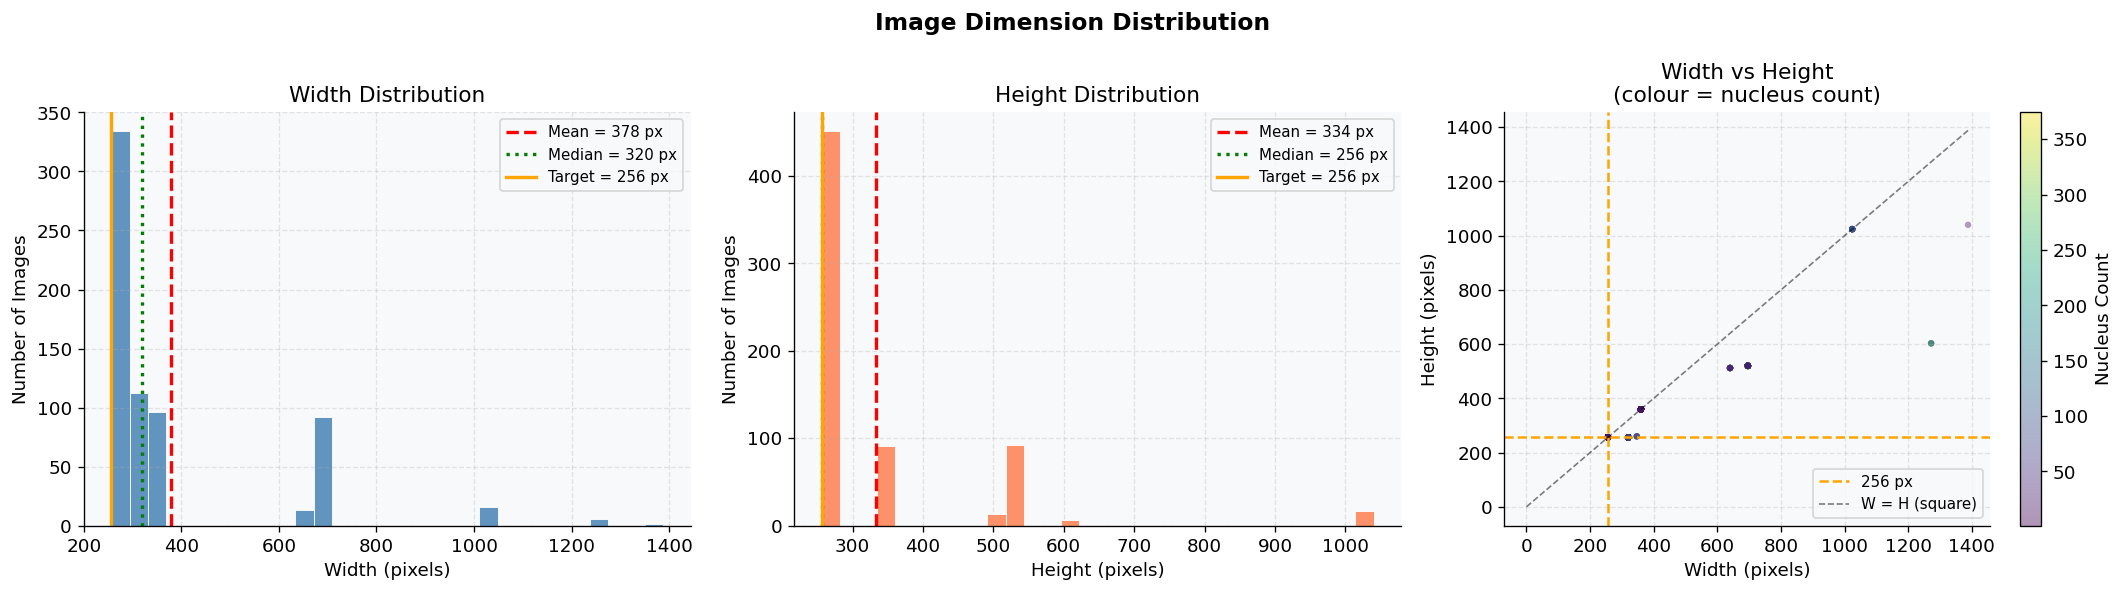

Saved: eda_size_distribution.png

Top 10 most frequent image sizes (W x H):
    256 x 256    ->  334 images  (49.9%)
    320 x 256    ->  112 images  (16.7%)
    696 x 520    ->   92 images  (13.7%)
    360 x 360    ->   91 images  (13.6%)
   1024 x 1024   ->   16 images  (2.4%)
    640 x 512    ->   13 images  (1.9%)
   1272 x 603    ->    6 images  (0.9%)
    347 x 260    ->    5 images  (0.7%)
   1388 x 1040   ->    1 images  (0.1%)

Finding : 9 distinct sizes ranging from 256 to 1388 px wide.
          The most common size is 256x256 (334 images, 49.9%).
Decision: Resize all images to 256x256 using bilinear interpolation.
          Resize all masks to 256x256 using nearest-neighbour interpolation
          (nearest-neighbour preserves binary values, avoiding sub-pixel artefacts).
          256x256 is divisible by 2^4 = 16, satisfying the UNet requirement
          that input dimensions be divisible by 2^(encoder depth).
          A standard depth-4 UNet contains 4 MaxPool2d downsam

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Image Dimension Distribution', fontsize=14, fontweight='bold')

# _tw / _th: convenience aliases for TARGET_SIZE (defined in Section 2).
# No new value is introduced here — these are read-only references to the
# top-level constant. Changing TARGET_SIZE in Section 2 automatically
# propagates to all three panels below.
_tw, _th = TARGET_SIZE


# Panel 1: Width histogram
ax = axes[0]
ax.hist(df['width'], bins=30, color='steelblue', edgecolor='white', linewidth=0.6, alpha=0.85)
ax.axvline(df['width'].mean(),   color='red',    linestyle='--', lw=2,
           label=f'Mean = {df["width"].mean():.0f} px')
ax.axvline(df['width'].median(), color='green',  linestyle=':',  lw=2,
           label=f'Median = {df["width"].median():.0f} px')
ax.axvline(_tw,                  color='orange', linestyle='-',  lw=2,
           label=f'Target = {_tw} px')
ax.set_xlabel('Width (pixels)')
ax.set_ylabel('Number of Images')
ax.set_title('Width Distribution')
ax.legend(fontsize=9)


# Panel 2: Height histogram
ax = axes[1]
ax.hist(df['height'], bins=30, color='coral', edgecolor='white', linewidth=0.6, alpha=0.85)
ax.axvline(df['height'].mean(),   color='red',    linestyle='--', lw=2,
           label=f'Mean = {df["height"].mean():.0f} px')
ax.axvline(df['height'].median(), color='green',  linestyle=':',  lw=2,
           label=f'Median = {df["height"].median():.0f} px')
ax.axvline(_th,                   color='orange', linestyle='-',  lw=2,
           label=f'Target = {_th} px')
ax.set_xlabel('Height (pixels)')
ax.set_ylabel('Number of Images')
ax.set_title('Height Distribution')
ax.legend(fontsize=9)


# Panel 3: Width vs Height scatter coloured by nucleus count
# Each point represents one image.  Points above the main diagonal are taller
# than they are wide (portrait); points below are wider (landscape).
# The reference lines mark the target resolution; proximity to their
# intersection indicates how much spatial information is preserved by resizing.
ax = axes[2]
scatter = ax.scatter(df['width'], df['height'], alpha=0.4, s=15,
                     c=df['n_nuclei'], cmap='viridis', edgecolors='none')
ax.axvline(_tw, color='orange', linestyle='--', lw=1.5, label=f'{_tw} px')
ax.axhline(_th, color='orange', linestyle='--', lw=1.5)
max_dim = df[['width', 'height']].max().max()
ax.plot([0, max_dim], [0, max_dim], 'k--', lw=1, alpha=0.5, label='W = H (square)')
ax.set_xlabel('Width (pixels)')
ax.set_ylabel('Height (pixels)')
ax.set_title('Width vs Height\n(colour = nucleus count)')
ax.legend(fontsize=9)
plt.colorbar(scatter, ax=ax, label='Nucleus Count')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}eda_size_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_size_distribution.png')


# Tabulate the most common sizes to inform the resizing decision.
size_counts = Counter(zip(df['width'], df['height']))
print('\nTop 10 most frequent image sizes (W x H):')
for (w_s, h_s), count in size_counts.most_common(10):
    print(f'  {w_s:>5} x {h_s:<5}  ->  {count:>3} images  ({count/len(df)*100:.1f}%)')

# Derive the most-common-size label dynamically from the scan data.
# _target_str comes from Section 2 — no second definition created here.
_most_common_size, _most_common_cnt = size_counts.most_common(1)[0]
_most_common_str = f'{_most_common_size[0]}x{_most_common_size[1]}'

print(f'\nFinding : {len(set(zip(df.width, df.height)))} distinct sizes ranging from '
      f'{df.width.min()} to {df.width.max()} px wide.')
print(f'          The most common size is {_most_common_str} ({_most_common_cnt} images, '
      f'{_most_common_cnt/len(df)*100:.1f}%).')
print(f'Decision: Resize all images to {_target_str} using bilinear interpolation.')
print(f'          Resize all masks to {_target_str} using nearest-neighbour interpolation')
print('          (nearest-neighbour preserves binary values, avoiding sub-pixel artefacts).')
print(f'          {_target_str} is divisible by 2^4 = 16, satisfying the UNet requirement')
print('          that input dimensions be divisible by 2^(encoder depth).')
print('          A standard depth-4 UNet contains 4 MaxPool2d downsampling operations,')
print('          requiring both spatial dimensions to be multiples of 16.')


## 6. Channel Type Analysis

Consistent input dimensions — including the number of channels — are required before feeding images into a neural network. This section determines whether the dataset contains mixed channel configurations that must be standardised.

**Finding from the scan (Section 4).** The full scan confirmed that all 670 images in this dataset are RGBA (4-channel). Charts below are generated directly from scan results. All images are converted to RGB via `PIL .convert('RGB')` before any further processing.


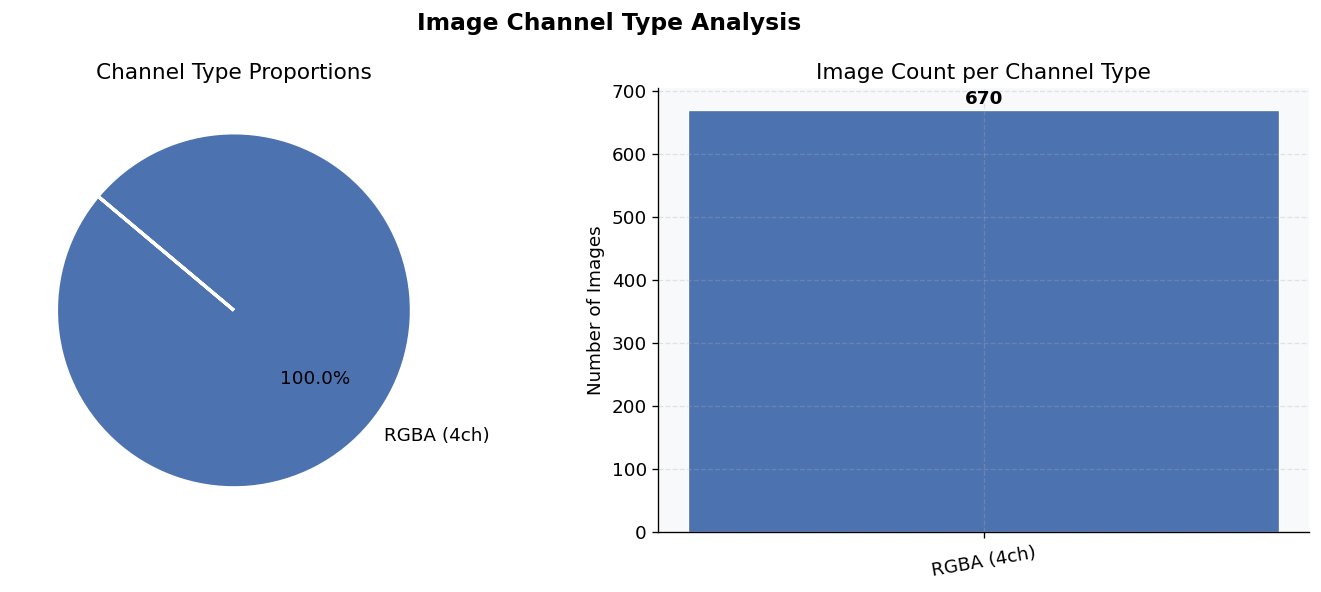

Saved: eda_channel_types.png

Finding : Channel distribution across all samples:
  RGBA (4ch)             :  670 images (100.0%)
  -> All 670 images share the same channel type: RGBA (4ch).
Decision: Convert all images to RGB via PIL .convert("RGB").
          This standardises all channel configurations to the 3-channel
          input format expected by UNet, and silently drops the alpha channel
          from RGBA images without introducing any additional processing step.


In [8]:
channel_map  = {1: 'Grayscale (1ch)', 3: 'RGB (3ch)', 4: 'RGBA (4ch)'}
channel_freq = df['n_channels'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Image Channel Type Analysis', fontsize=14, fontweight='bold')

labels = [channel_map.get(k, f'{k}ch') for k in channel_freq.index]
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']


# Panel 1: Proportional breakdown (pie chart)
axes[0].pie(
    channel_freq.values,
    labels=labels,
    colors=colors[:len(labels)],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 11}
)
axes[0].set_title('Channel Type Proportions')


# Panel 2: Absolute counts (bar chart)
bars = axes[1].bar(
    labels, channel_freq.values,
    color=colors[:len(labels)], edgecolor='white', linewidth=0.8
)
for bar, val in zip(bars, channel_freq.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(val), ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[1].set_ylabel('Number of Images')
axes[1].set_title('Image Count per Channel Type')
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, rotation=10)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}eda_channel_types.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_channel_types.png')


# Determine the dominant channel type and compose the finding string
# dynamically from the scan results.  A single conditional distinguishes
# between a uniform dataset (all images share one type) and a mixed dataset.
dominant_ch  = channel_freq.idxmax()
dominant_lbl = channel_map.get(dominant_ch, f'{dominant_ch}ch')
dominant_cnt = channel_freq[dominant_ch]
is_uniform   = (len(channel_freq) == 1)

print('\nFinding : Channel distribution across all samples:')
for ch, count in channel_freq.items():
    print(f'  {channel_map.get(ch, str(ch)):<22} : {count:>4} images ({count/len(df)*100:.1f}%)')
if is_uniform:
    print(f'  -> All {len(df)} images share the same channel type: {dominant_lbl}.')
else:
    print(f'  -> Mixed channel types detected. Dominant type: {dominant_lbl} ({dominant_cnt} images).')
print('Decision: Convert all images to RGB via PIL .convert(\"RGB\").')
print('          This standardises all channel configurations to the 3-channel')
print('          input format expected by UNet, and silently drops the alpha channel')
print('          from RGBA images without introducing any additional processing step.')


## 7. Pixel Intensity Analysis

Pixel intensity distributions reveal the imaging conditions (dark fluorescence images vs. bright brightfield images) and the degree of contrast variation across samples. This directly informs the normalisation strategy applied in the preprocessing pipeline.

- The per-image mean intensities span a wide range (exact values are printed from the scan results below), confirming that raw pixel values cannot be fed directly to the network without normalisation.
- Two normalisation strategies are available; the binding choice is deferred to the preprocessing notebook once the encoder architecture is confirmed.

**Normalisation options:**

| Option | When to use | Operation |
|:---|:---|:---|
| **A — Pre-trained ImageNet encoder** (e.g. ResNet-34 backbone) | Transfer learning from ImageNet weights | `albumentations.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])` divides by 255 then subtracts the per-channel ImageNet mean and divides by the per-channel ImageNet std, producing output in roughly `[−2.1, 2.6]` per channel |
| **B — UNet trained from scratch** (no pre-trained encoder) | Training from random initialisation on microscopy data | Divide pixel values by 255 to rescale to `[0, 1]`; ImageNet statistics are not meaningful for fluorescence or brightfield microscopy |

> **Important:** `albumentations.Normalize` with ImageNet statistics **does not** simply rescale to `[0, 1]`. It first divides by 255 (implicit) then applies per-channel standardisation: `output = (pixel / 255 − mean) / std`. Using this transform with Option B (scratch training) would apply meaningless ImageNet statistics to microscopy data and is incorrect. Use Option B (divide by 255 only) when no pre-trained encoder is used.


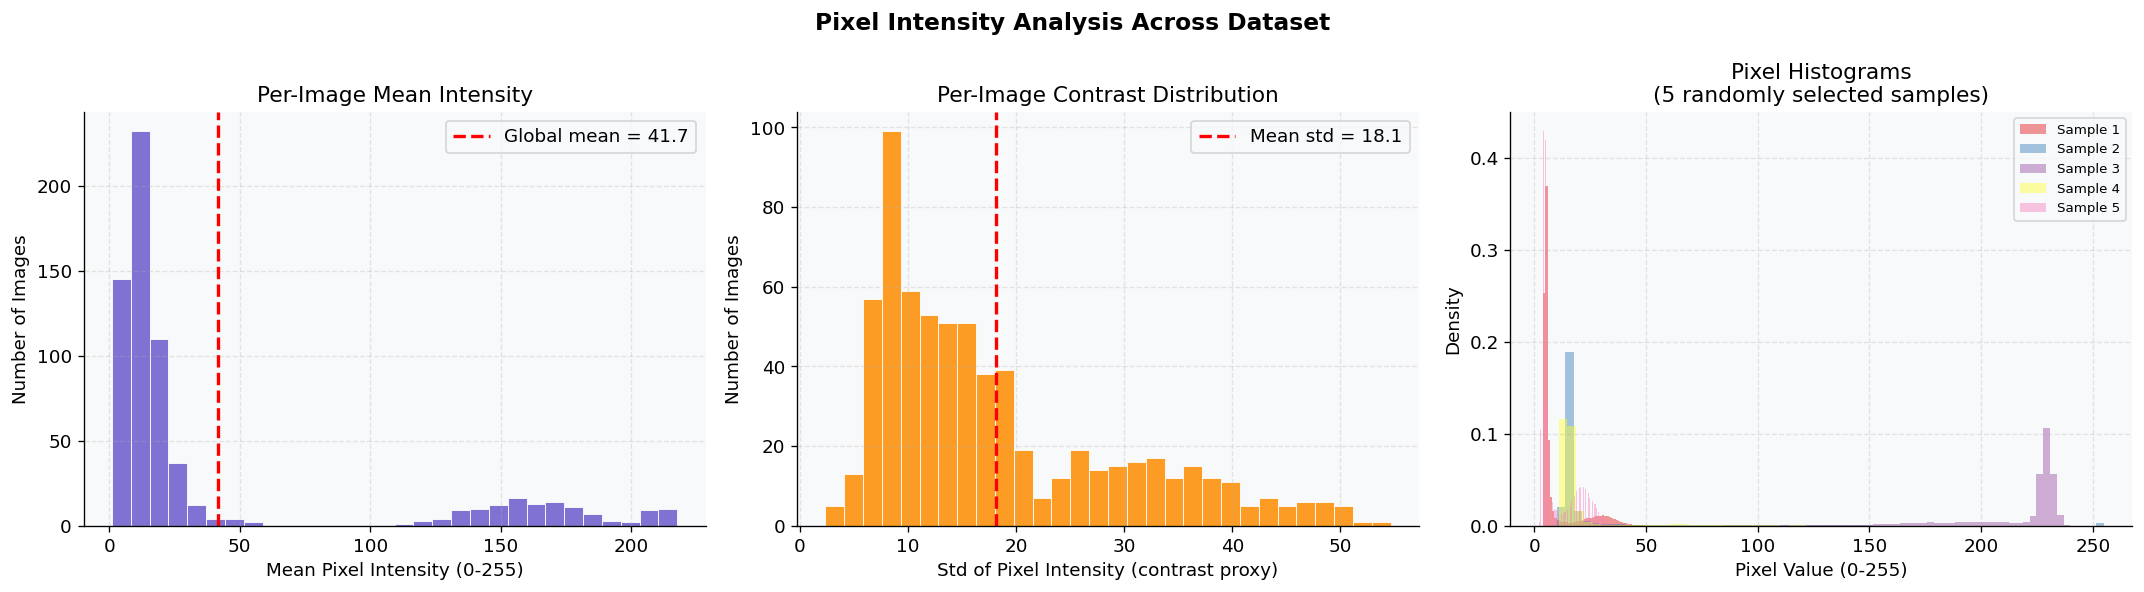

Saved: eda_intensity_analysis.png

Finding : Per-image mean intensity ranges from 1.0 to 217.8 (grayscale, 0-255 scale).
          This wide range reflects the co-existence of dark fluorescence images
          and bright brightfield images in the same dataset.
Decision (Option B — binding): Normalise by dividing pixel values by 255
          → float32 output in [0.0, 1.0].
          Rationale: UNet trained from scratch; no pre-trained encoder.
          Option A (ImageNet mean/std) is NOT applied — not meaningful
          for fluorescence or brightfield microscopy data.
          Implementation: Notebook 02, normalise_image() → img / 255.0.


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Pixel Intensity Analysis Across Dataset', fontsize=14, fontweight='bold')


# Panel 1: Mean intensity per image — skew reflects mixed fluorescence/brightfield.
ax = axes[0]
ax.hist(df['mean_intensity'], bins=30, color='slateblue',
        edgecolor='white', linewidth=0.6, alpha=0.85)
ax.axvline(df['mean_intensity'].mean(), color='red', linestyle='--', lw=2,
           label=f'Global mean = {df["mean_intensity"].mean():.1f}')
ax.set_xlabel('Mean Pixel Intensity (0-255)')
ax.set_ylabel('Number of Images')
ax.set_title('Per-Image Mean Intensity')
ax.legend()


# Panel 2: Contrast proxy (pixel std) — high variance motivates per-image normalisation.
ax = axes[1]
ax.hist(df['std_intensity'], bins=30, color='darkorange',
        edgecolor='white', linewidth=0.6, alpha=0.85)
ax.axvline(df['std_intensity'].mean(), color='red', linestyle='--', lw=2,
           label=f'Mean std = {df["std_intensity"].mean():.1f}')
ax.set_xlabel('Std of Pixel Intensity (contrast proxy)')
ax.set_ylabel('Number of Images')
ax.set_title('Per-Image Contrast Distribution')
ax.legend()


# Panel 3: Overlaid histograms for 5 samples — illustrates inter-sample variation.
ax = axes[2]
random.seed(SEED)
sample_ids_5 = random.sample(ALL_IDS, 5)
palette      = plt.cm.Set1(np.linspace(0, 0.8, 5))
for i, sid in enumerate(sample_ids_5):
    img_path = os.path.join(DRIVE_ROOT, sid, 'images', f'{sid}.png')
    if not os.path.exists(img_path):
        img_files = [f for f in os.listdir(os.path.join(DRIVE_ROOT, sid, 'images'))
                     if f.endswith('.png')]
        img_path = os.path.join(DRIVE_ROOT, sid, 'images', img_files[0])
    # Grayscale conversion: channel-agnostic intensity for all image types.
    with Image.open(img_path) as _img:
        img_gray = np.array(_img.convert('L'), dtype=np.float32).ravel()
    ax.hist(img_gray, bins=64, density=True, alpha=0.45,
            color=palette[i], label=f'Sample {i+1}', linewidth=0)
ax.set_xlabel('Pixel Value (0-255)')
ax.set_ylabel('Density')
ax.set_title('Pixel Histograms\n(5 randomly selected samples)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}eda_intensity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_intensity_analysis.png')

print(f'\nFinding : Per-image mean intensity ranges from {df["mean_intensity"].min():.1f} to '
      f'{df["mean_intensity"].max():.1f} (grayscale, 0-255 scale).')
print(f'          This wide range reflects the co-existence of dark fluorescence images')
print(f'          and bright brightfield images in the same dataset.')

# Normalisation strategy is selected during preprocessing to remain
# independent of model architecture decisions during EDA.

# Two standard approaches were considered:
#   • ImageNet mean/std normalisation for transfer-learning pipelines.
#   • Pixel rescaling to [0, 1] for microscopy-specific training workflows.

# The final implementation is applied in Notebook 02 via normalise_image().
print('Decision (Option B — binding): Normalise by dividing pixel values by 255')
print('          → float32 output in [0.0, 1.0].')
print('          Rationale: UNet trained from scratch; no pre-trained encoder.')
print('          Option A (ImageNet mean/std) is NOT applied — not meaningful')
print('          for fluorescence or brightfield microscopy data.')
print('          Implementation: Notebook 02, normalise_image() → img / 255.0.')


## 8. Nucleus Count Distribution

The number of nuclei per image serves as a proxy for **task difficulty**: images with many small, densely packed nuclei are harder to segment accurately than images with few well-separated nuclei. Characterising this distribution is important for three reasons:

1. It reveals the range of complexity the model must handle.
2. It quantifies the right-skew that justifies stratified splitting.
3. It confirms that instance masks must be merged into a single binary mask for the binary segmentation task.


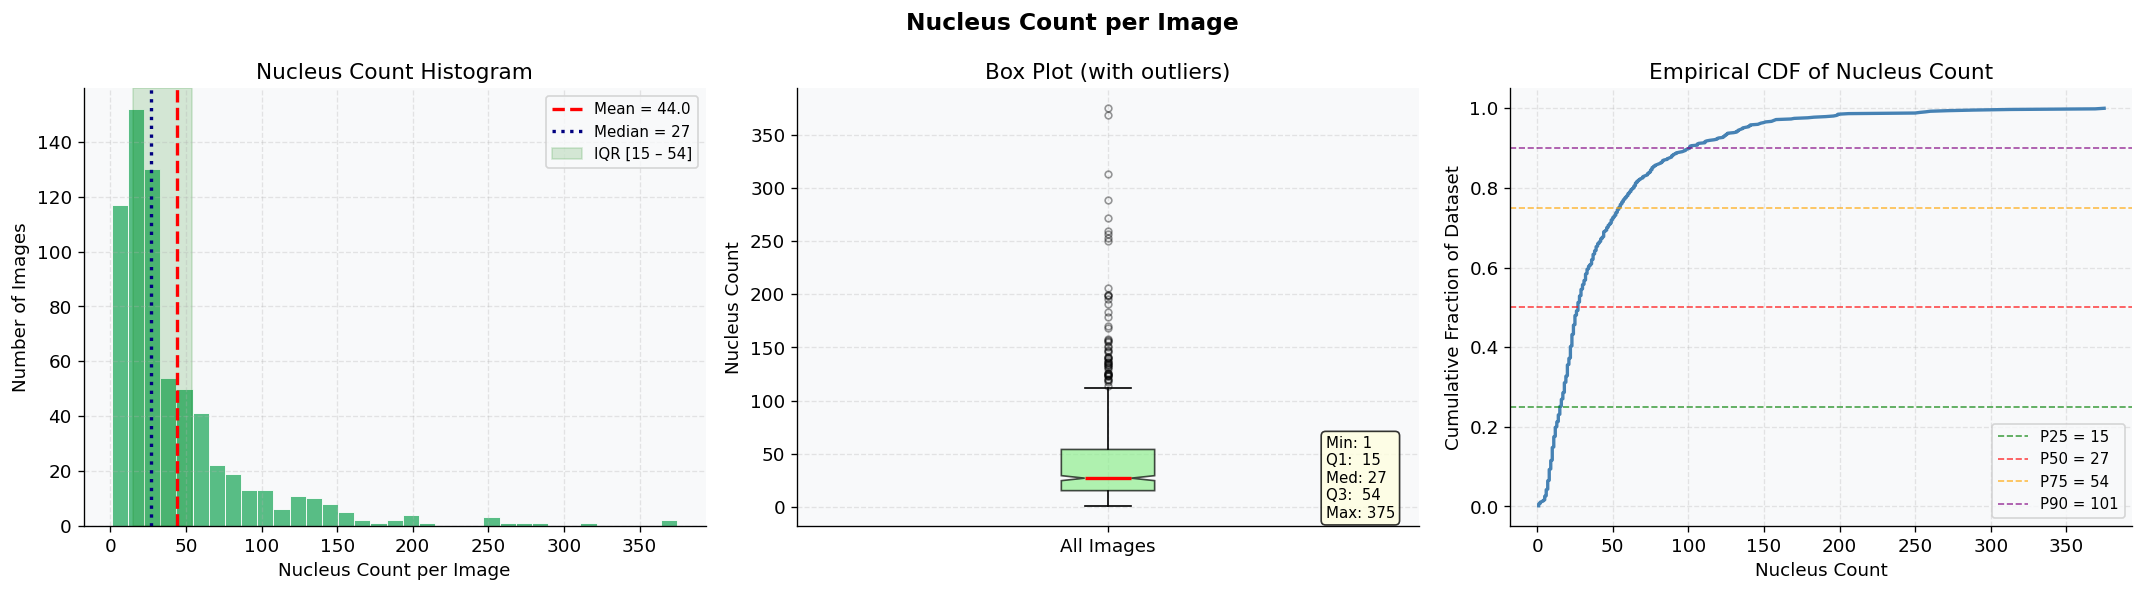

Saved: eda_nucleus_counts.png

Outlier analysis (top 5% by nucleus count, threshold > 136):
  High-density images: 33 — performance on these should be
  reported separately in the evaluation section.
  Note: threshold is exclusive (>) — images strictly above P95 are flagged.

Finding : Nucleus counts range from 1 to 375
          (mean = 44.0, median = 27).
          The distribution is strongly right-skewed.
Decision: Merge all per-nucleus instance masks into a single binary mask
          using np.maximum(), converting the problem to binary segmentation.
          Use nucleus count quartiles to stratify the train/val/test split.


In [10]:
q25, q75 = df['n_nuclei'].quantile([0.25, 0.75])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Nucleus Count per Image', fontsize=14, fontweight='bold')


# Panel 1: Histogram with statistical reference lines
ax = axes[0]
ax.hist(df['n_nuclei'], bins=35, color='mediumseagreen',
        edgecolor='white', linewidth=0.6, alpha=0.85)
ax.axvline(df['n_nuclei'].mean(),   color='red',  linestyle='--', lw=2,
           label=f'Mean = {df["n_nuclei"].mean():.1f}')
ax.axvline(df['n_nuclei'].median(), color='navy', linestyle=':',  lw=2,
           label=f'Median = {df["n_nuclei"].median():.0f}')
ax.axvspan(q25, q75, alpha=0.15, color='green',
           label=f'IQR [{q25:.0f} – {q75:.0f}]')
ax.set_xlabel('Nucleus Count per Image')
ax.set_ylabel('Number of Images')
ax.set_title('Nucleus Count Histogram')
ax.legend(fontsize=9)


# Panel 2: Notched box plot
# The notch represents the 95% confidence interval around the median.
# Data points beyond 1.5 × IQR from the box edges are rendered as individual
# markers and treated as statistical outliers for reporting purposes.
ax = axes[1]
ax.boxplot(
    df['n_nuclei'], patch_artist=True, notch=True, vert=True,
    medianprops=dict(color='red', linewidth=2),
    boxprops=dict(facecolor='lightgreen', alpha=0.7),
    flierprops=dict(marker='o', color='gray', alpha=0.4, markersize=4)
)
ax.set_ylabel('Nucleus Count')
ax.set_title('Box Plot (with outliers)')
ax.set_xticks([1])
ax.set_xticklabels(['All Images'])
stats_text = (
    f'Min: {df["n_nuclei"].min()}\n'
    f'Q1:  {q25:.0f}\n'
    f'Med: {df["n_nuclei"].median():.0f}\n'
    f'Q3:  {q75:.0f}\n'
    f'Max: {df["n_nuclei"].max()}'
)
ax.text(1.35, df['n_nuclei'].median(), stats_text, fontsize=9, va='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))


# Panel 3: Empirical cumulative distribution function
# The ECDF provides a non-parametric view of the full distribution without
# any binning artefacts.  Annotated percentile lines allow direct read-off
# of the count thresholds used for stratified splitting.
ax = axes[2]
sorted_counts = np.sort(df['n_nuclei'])
cdf = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts)
ax.plot(sorted_counts, cdf, color='steelblue', linewidth=2)
for p, clr in [(0.25, 'green'), (0.50, 'red'), (0.75, 'orange'), (0.90, 'purple')]:
    val = np.percentile(df['n_nuclei'], p * 100)
    ax.axhline(p, color=clr, linestyle='--', linewidth=1, alpha=0.7,
               label=f'P{int(p*100)} = {val:.0f}')
ax.set_xlabel('Nucleus Count')
ax.set_ylabel('Cumulative Fraction of Dataset')
ax.set_title('Empirical CDF of Nucleus Count')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}eda_nucleus_counts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_nucleus_counts.png')

# The outlier threshold is exclusive (strictly greater than P95) so that
# the reported count represents samples in the top percentile without
# including the boundary value itself.
outlier_thresh = df['n_nuclei'].quantile(0.95)
n_outliers     = int((df['n_nuclei'] > outlier_thresh).sum())
print(f'\nOutlier analysis (top 5% by nucleus count, threshold > {outlier_thresh:.0f}):')
print(f'  High-density images: {n_outliers} — performance on these should be')
print(f'  reported separately in the evaluation section.')
print(f'  Note: threshold is exclusive (>) — images strictly above P95 are flagged.')
print(f'\nFinding : Nucleus counts range from {df["n_nuclei"].min()} to {df["n_nuclei"].max()}')
print(f'          (mean = {df["n_nuclei"].mean():.1f}, median = {df["n_nuclei"].median():.0f}).')
print(f'          The distribution is strongly right-skewed.')
print('Decision: Merge all per-nucleus instance masks into a single binary mask')
print('          using np.maximum(), converting the problem to binary segmentation.')
print('          Use nucleus count quartiles to stratify the train/val/test split.')


## 9. Mask Coverage and Class Imbalance

The mask coverage ratio — the fraction of image pixels labelled as foreground (nuclei) — is the primary indicator of class imbalance. In medical image segmentation, the foreground typically occupies a small fraction of each image, meaning a naive classifier that predicts all-background achieves high pixel accuracy while learning nothing.

This section quantifies the imbalance and determines the appropriate loss function and evaluation metrics.


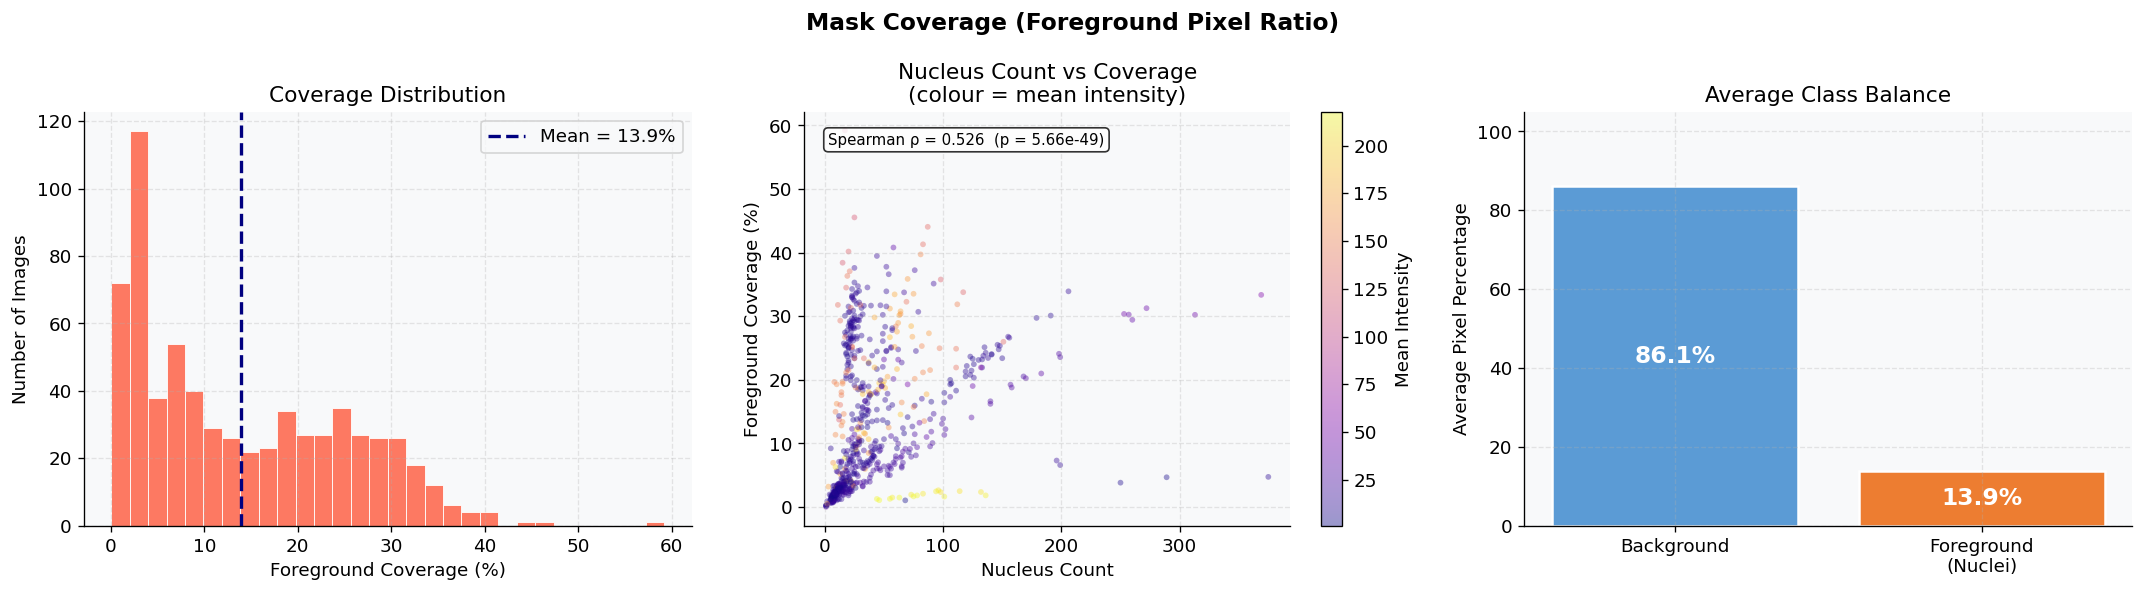

Saved: eda_mask_coverage.png

Finding : Average foreground coverage = 13.9%  |  background = 86.1%.
          Spearman correlation (nucleus count vs coverage) = 0.526
          This confirms moderate positive correlation: images with more nuclei
          tend to have higher foreground coverage, as expected.
Decision: Use Dice Loss as the primary training objective.
          Dice Loss is inherently insensitive to class imbalance because it
          measures overlap rather than per-pixel cross-entropy.
          Evaluation metrics: Dice coefficient and Intersection over Union (IoU).
          Pixel accuracy is not reported as a primary metric due to class imbalance.


In [11]:
mean_fg = df['coverage_ratio'].mean() * 100
mean_bg = 100 - mean_fg

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Mask Coverage (Foreground Pixel Ratio)', fontsize=14, fontweight='bold')


# Panel 1: Distribution of coverage ratios
ax = axes[0]
ax.hist(df['coverage_ratio'] * 100, bins=30, color='tomato',
        edgecolor='white', linewidth=0.6, alpha=0.85)
ax.axvline(mean_fg, color='navy', linestyle='--', lw=2,
           label=f'Mean = {mean_fg:.1f}%')
ax.set_xlabel('Foreground Coverage (%)')
ax.set_ylabel('Number of Images')
ax.set_title('Coverage Distribution')
ax.legend()


# Panel 2: Nucleus count vs foreground coverage scatter
# Spearman rank correlation is used instead of Pearson because the nucleus
# count distribution is right-skewed (see the nucleus-count analysis above),
# which violates the normality assumption underlying Pearson's r.
# Spearman's rho is a non-parametric rank-based measure and is robust to
# skewed distributions and outliers.
ax = axes[1]
sc = ax.scatter(
    df['n_nuclei'], df['coverage_ratio'] * 100,
    alpha=0.4, s=12, c=df['mean_intensity'], cmap='plasma', edgecolors='none'
)
ax.set_xlabel('Nucleus Count')
ax.set_ylabel('Foreground Coverage (%)')
ax.set_title('Nucleus Count vs Coverage\n(colour = mean intensity)')
plt.colorbar(sc, ax=ax, label='Mean Intensity')
r, p = stats.spearmanr(df['n_nuclei'], df['coverage_ratio'])
ax.text(0.05, 0.95, f'Spearman ρ = {r:.3f}  (p = {p:.2e})',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# Panel 3: Average class balance summary
# The foreground label y-position is guarded with a minimum of 2.5% to keep
# the text visible if mean_fg is very small (e.g. in a low-coverage subset).
# On DSB 2018 the foreground fraction is ~13.9% (EDA Sec.9), so the guard
# does not trigger in practice; it is retained for robustness.
ax = axes[2]
ax.bar(
    ['Background', 'Foreground\n(Nuclei)'],
    [mean_bg, mean_fg],
    color=['#5B9BD5', '#ED7D31'], edgecolor='white', linewidth=1.5
)
ax.text(0, mean_bg / 2, f'{mean_bg:.1f}%', ha='center', va='center',
        fontsize=14, fontweight='bold', color='white')
fg_label_y = max(mean_fg / 2, 2.5)
ax.text(1, fg_label_y, f'{mean_fg:.1f}%', ha='center', va='center',
        fontsize=14, fontweight='bold', color='white')
ax.set_ylabel('Average Pixel Percentage')
ax.set_title('Average Class Balance')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}eda_mask_coverage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_mask_coverage.png')

print(f'\nFinding : Average foreground coverage = {mean_fg:.1f}%  |  background = {mean_bg:.1f}%.')
print(f'          Spearman correlation (nucleus count vs coverage) = {r:.3f}')
print(f'          This confirms moderate positive correlation: images with more nuclei')
print(f'          tend to have higher foreground coverage, as expected.')
print('Decision: Use Dice Loss as the primary training objective.')
print('          Dice Loss is inherently insensitive to class imbalance because it')
print('          measures overlap rather than per-pixel cross-entropy.')
print('          Evaluation metrics: Dice coefficient and Intersection over Union (IoU).')
print('          Pixel accuracy is not reported as a primary metric due to class imbalance.')


## 10. Visual Sample Inspection

Quantitative statistics alone cannot reveal all relevant dataset properties. This section provides a qualitative inspection of representative samples, deliberately selected from the low, medium, and high nucleus count strata.

Each row shows three views of the same sample:
- **Original image** — the raw microscopy image as stored on disk
- **Combined binary mask** — all instance masks merged into one foreground map
- **Overlay** — the binary mask superimposed on the original image


In [12]:
def open_image(sid):
    """Load the microscopy image for a given sample ID as a (H, W, 3) uint8 array.

    The function resolves the canonical image path (filename == sample ID) and
    falls back to the first PNG in the images/ directory for samples whose
    filename does not match the directory name — a known variant in some Kaggle
    download archives.  The file handle is opened and closed inside this
    function; the caller receives a plain NumPy array and does not need to
    manage any I/O resources.

    Parameters
    sid : str
        Sample identifier (SHA-256 directory name).

    Returns
    np.ndarray
        Shape (H, W, 3), dtype uint8, RGB channel order.
    """
    path = os.path.join(DRIVE_ROOT, sid, 'images', f'{sid}.png')
    if not os.path.exists(path):
        files = [f for f in os.listdir(os.path.join(DRIVE_ROOT, sid, 'images'))
                 if f.endswith('.png')]
        if not files:
            raise FileNotFoundError(f'No PNG image found for sample {sid}')
        path = os.path.join(DRIVE_ROOT, sid, 'images', files[0])
    with Image.open(path) as _img:
        return np.array(_img.convert('RGB'), dtype=np.uint8)


def build_combined_mask(sid, height, width):
    """Construct the merged binary foreground mask for a given sample.

    Each instance mask PNG is opened, optionally resized to (height, width)
    with nearest-neighbour interpolation to handle any dimension mismatches,
    and merged into a running maximum array.  The result is the binary target
    mask used during UNet training.

    This function performs disk reads.  It is intended only for the small
    subset of samples selected for visual inspection; it is not called during
    the main statistics scan.

    Parameters
    sid    : str   Sample identifier.
    height : int   Target height in pixels.
    width  : int   Target width in pixels.

    Returns
    np.ndarray
        Shape (height, width), dtype uint8, values in {0, 255}.
    """
    mask_dir      = os.path.join(DRIVE_ROOT, sid, 'masks')
    combined_mask = np.zeros((height, width), dtype=np.uint8)
    for mf in os.listdir(mask_dir):
        if mf.endswith('.png'):
            with Image.open(os.path.join(mask_dir, mf)) as _raw_mask:
                m_pil = _raw_mask.convert('L')
            # Resize to the target dimensions only when necessary to preserve
            # the binary {0, 255} pixel values via nearest-neighbour sampling.
            if m_pil.size != (width, height):
                m_pil = m_pil.resize((width, height), resample=Image.NEAREST)
            m = np.array(m_pil, dtype=np.uint8)
            combined_mask = np.maximum(combined_mask, m)
    return combined_mask


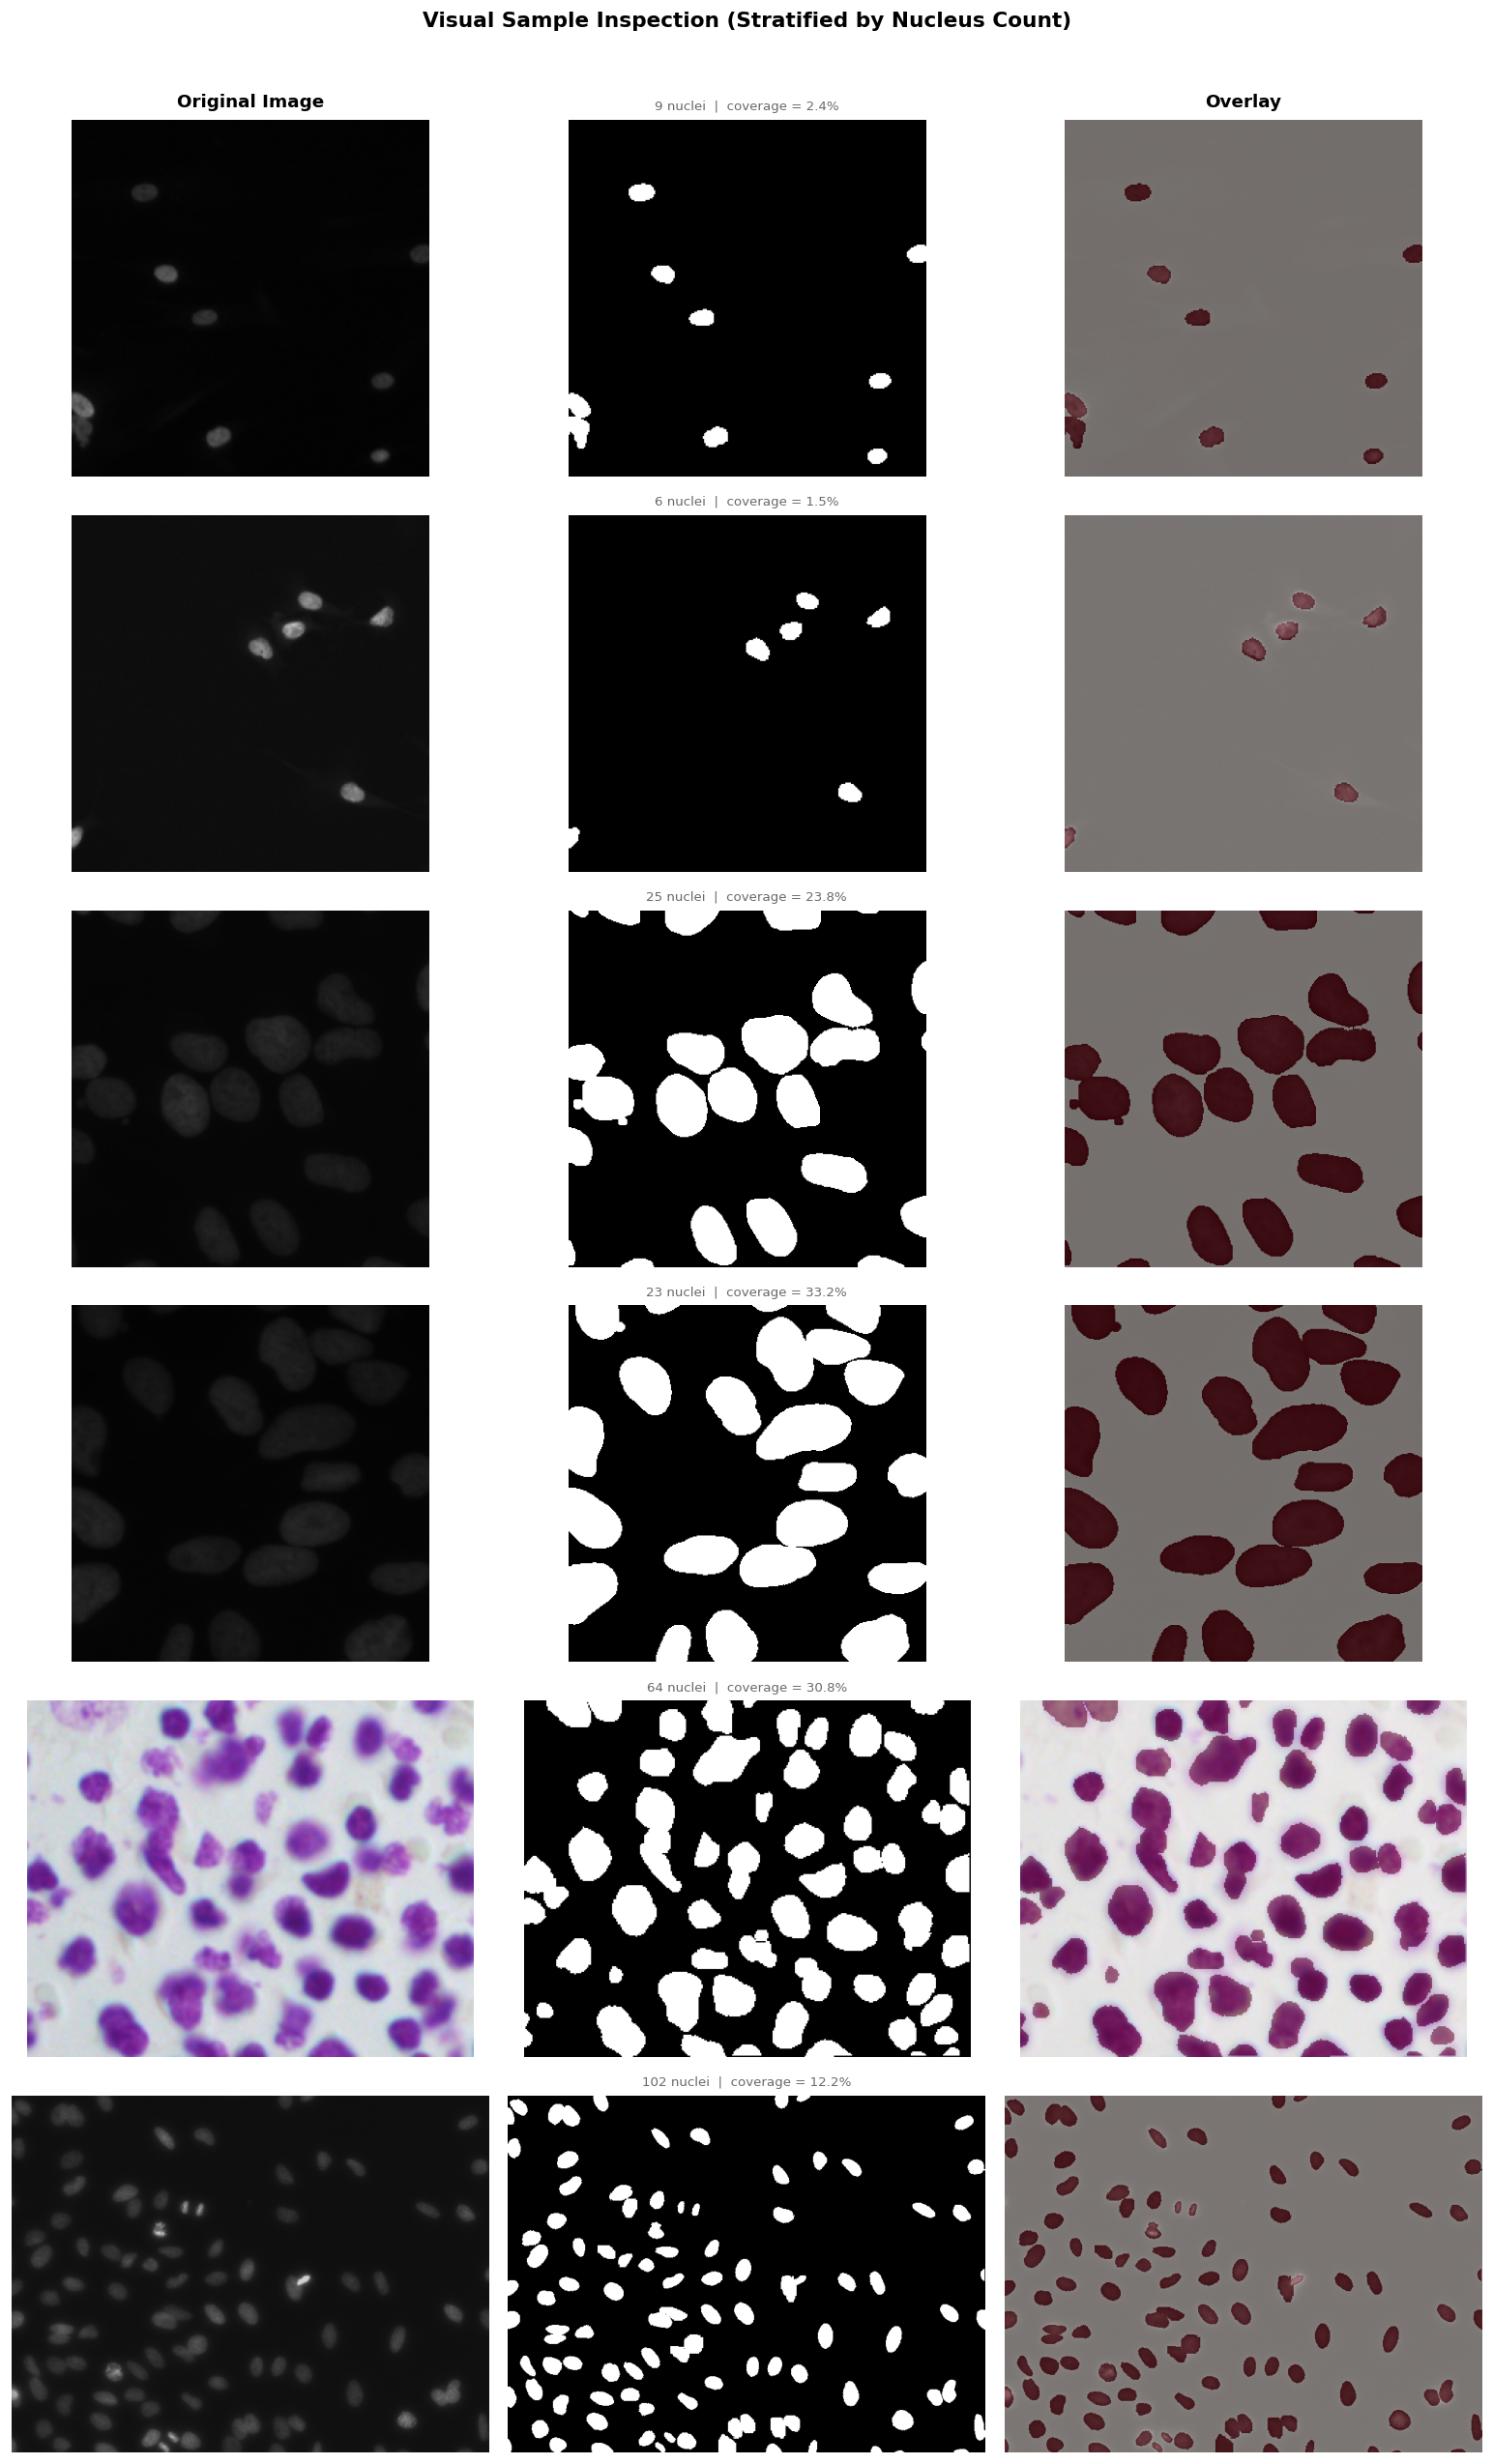

Saved: eda_visual_samples.png

Observation: The dataset contains both fluorescence and brightfield microscopy images.
  Images differ substantially in background intensity, staining colour,
  nucleus morphology, and packing density.
  This heterogeneity reinforces the need for aggressive data augmentation
  to improve model generalisation across imaging modalities.


In [13]:
# Select 2 representative samples from each of three nucleus-density strata
# (low, medium, high) to provide a qualitative cross-section of dataset
# complexity.  Quantile boundaries define the strata consistently with the
# nucleus-count analysis above.
low_n  = df[df['n_nuclei'] <= df['n_nuclei'].quantile(0.20)].sample(2, random_state=SEED)['id'].tolist()
mid_n  = df[(df['n_nuclei'] > df['n_nuclei'].quantile(0.40)) &
            (df['n_nuclei'] <= df['n_nuclei'].quantile(0.60))].sample(2, random_state=SEED)['id'].tolist()
high_n = df[df['n_nuclei'] >= df['n_nuclei'].quantile(0.80)].sample(2, random_state=SEED)['id'].tolist()

selected       = low_n + mid_n + high_n
density_labels = ['Low Density'] * 2 + ['Medium Density'] * 2 + ['High Density'] * 2
N              = len(selected)

fig, axes = plt.subplots(N, 3, figsize=(13, N * 3.5))
fig.suptitle(
    'Visual Sample Inspection (Stratified by Nucleus Count)',
    fontsize=13, fontweight='bold', y=1.01
)

for j, col_title in enumerate(['Original Image', 'Combined Binary Mask', 'Overlay']):
    axes[0][j].set_title(col_title, fontsize=11, fontweight='bold', pad=8)

for i, (sid, density_label) in enumerate(zip(selected, density_labels)):
    # open_image() returns a (H, W, 3) uint8 array; no further PIL conversion
    # is required and no file handle needs to be managed by the caller.
    img       = open_image(sid)
    h, w      = img.shape[:2]
    n_nuc     = int(df.loc[df['id'] == sid, 'n_nuclei'].values[0])
    cov       = float(df.loc[df['id'] == sid, 'coverage_ratio'].values[0])
    comb_mask = build_combined_mask(sid, h, w)

    axes[i][0].imshow(img)
    axes[i][0].set_ylabel(
        f'{density_label}\n{w} x {h} px',
        rotation=0, labelpad=95, va='center', fontsize=8
    )

    axes[i][1].imshow(comb_mask, cmap='gray', vmin=0, vmax=255)
    axes[i][1].set_title(
        f'{n_nuc} nuclei  |  coverage = {cov*100:.1f}%',
        fontsize=8, color='dimgray'
    )

    axes[i][2].imshow(img)
    axes[i][2].imshow(comb_mask, alpha=0.45, cmap='Reds', vmin=0, vmax=255)

    # Use 'col' as the inner loop variable to avoid shadowing the outer 'j'
    # from the column-title enumeration above.
    for col in range(3):
        axes[i][col].axis('off')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}eda_visual_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_visual_samples.png')
print('\nObservation: The dataset contains both fluorescence and brightfield microscopy images.')
print('  Images differ substantially in background intensity, staining colour,')
print('  nucleus morphology, and packing density.')
print('  This heterogeneity reinforces the need for aggressive data augmentation')
print('  to improve model generalisation across imaging modalities.')


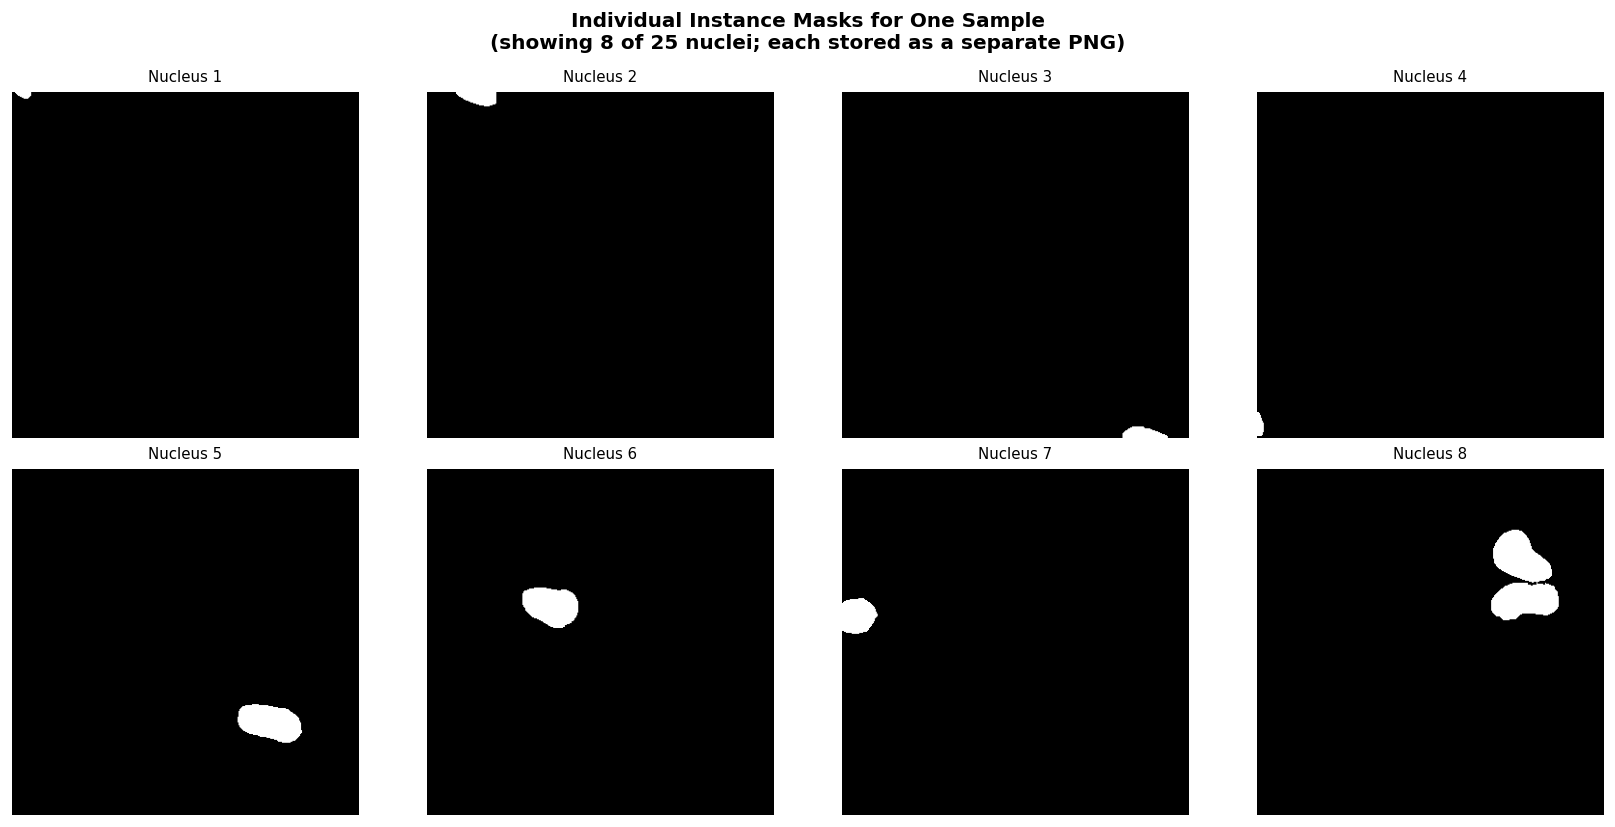

Saved: eda_instance_masks.png

Observation: Each nucleus occupies its own binary PNG file.
  Preprocessing action: merge all instance masks per sample using
  np.maximum() to produce a single foreground/background binary mask.


In [14]:
# Display a subset of individual instance mask PNGs for one representative
# sample to illustrate the raw storage format of the DSB 2018 dataset.
# Each nucleus is stored as a separate binary PNG file; the preprocessing
# pipeline must merge all per-nucleus masks into a single binary target mask.
demo_sid   = mid_n[0]
mask_dir   = os.path.join(DRIVE_ROOT, demo_sid, 'masks')
mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith('.png')])

n_show = min(8, len(mask_files))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle(
    f'Individual Instance Masks for One Sample\n'
    f'(showing {n_show} of {len(mask_files)} nuclei; each stored as a separate PNG)',
    fontsize=12, fontweight='bold'
)

for idx, ax in enumerate(axes.flat):
    if idx < n_show:
        with Image.open(os.path.join(mask_dir, mask_files[idx])) as _m:
            m = np.array(_m.convert('L'))
        ax.imshow(m, cmap='gray')
        ax.set_title(f'Nucleus {idx+1}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}eda_instance_masks.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_instance_masks.png')
print('\nObservation: Each nucleus occupies its own binary PNG file.')
print('  Preprocessing action: merge all instance masks per sample using')
print('  np.maximum() to produce a single foreground/background binary mask.')


## 11. Mask Quality and Validity Checks

Before any mask can be trusted as a training label, three validity criteria must be satisfied:

| Check | Criterion | Consequence if violated |
|:---|:---|:---|
| Binary values | Mask contains only `{0, 255}` | Intermediate values introduce ambiguous labels |
| Non-empty | Mask has at least one foreground pixel | Empty masks contribute zero gradient to Dice Loss |
| Size consistency | Mask spatial dimensions equal image dimensions | Misaligned masks produce incorrect pixel-level supervision |

Quality flags were collected during the single-pass scan in Section 4. No additional I/O is required here.


In [15]:
# Mask quality report — counters populated during the scan (Cell 09).

print('              MASK QUALITY REPORT')
print(f'  Total instance masks checked   : {total_masks_checked}')
print(f'  Non-binary masks (not 0/255)   : {non_binary_count}')
print(f'  Empty masks (all zeros)        : {empty_mask_count}')
print(f'  Size mismatches with image     : {size_mismatch_count}')

if non_binary_count > 0:
    print(f'\nWARNING: Non-binary mask examples (first 3):')
    for sid, mf, vals in non_binary_examples:
        print(f'  Sample: {sid[:12]}...  Mask: {mf[:16]}...  Pixel range: {vals}')
    print('  Remediation: apply a >127 threshold during preprocessing to binarise.')
else:
    print('  PASS: All masks contain only {0, 255} — labels are strictly binary.')

if empty_mask_count == 0:
    print('  PASS: No empty masks detected — all masks contain at least one foreground pixel.')
else:
    print(f'  WARNING: {empty_mask_count} empty masks detected.')
    print('           These samples should be excluded from training or investigated manually.')

if size_mismatch_count == 0:
    print('  PASS: All masks match their corresponding image dimensions.')
else:
    print(f'  WARNING: {size_mismatch_count} size mismatches detected.')
    print('           Affected masks must be resized to match the image before merging.')

print('\nDecision: Although all masks in this dataset pass all three validity checks,')
print('  a >127 threshold binarisation step will be applied in the preprocessing')
print('  notebook as a defensive measure to handle edge cases in unseen data.')
print('  Augmentation of the merged binary masks is handled in the augmentation notebook.')


              MASK QUALITY REPORT
  Total instance masks checked   : 29461
  Non-binary masks (not 0/255)   : 0
  Empty masks (all zeros)        : 0
  Size mismatches with image     : 0
  PASS: All masks contain only {0, 255} — labels are strictly binary.
  PASS: No empty masks detected — all masks contain at least one foreground pixel.
  PASS: All masks match their corresponding image dimensions.

Decision: Although all masks in this dataset pass all three validity checks,
  a >127 threshold binarisation step will be applied in the preprocessing
  notebook as a defensive measure to handle edge cases in unseen data.
  Augmentation of the merged binary masks is handled in the augmentation notebook.


## 12. Train / Validation / Test Split Strategy

The data split must be defined **before any preprocessing** to ensure that normalisation statistics (if computed on the training set) and augmentation policies do not propagate information from validation or test samples into the training process.

**Split rationale — 70 / 15 / 15:**

| Subset | Approximate count | Purpose |
|:---|:---|:---|
| Train | ~469 (70%) | Model training with augmentation |
| Validation | ~100 (15%) | Hyperparameter selection and early stopping |
| Test | ~101 (15%) | Held-out final evaluation — examined once only |

> **Note on counts:** 670 × 0.70 = 469 and 670 × 0.15 = 100.5. `train_test_split` rounds, so the actual val/test counts are either 100/101 or 101/100. The exact counts are printed in the split summary below. **Always use the printed exact counts in the report, not the approximate values above.**

**Stratification.** Splits are stratified by nucleus count quartile to ensure that easy (few nuclei) and difficult (many nuclei) images are proportionally represented in all three subsets. This prevents accidental concentration of hard examples in the test set, which would produce pessimistic evaluation metrics.

The resulting split IDs are written to text files and loaded by all subsequent notebooks. They must not be re-generated, as doing so with a different random state would constitute data leakage.


                  DATASET SPLIT SUMMARY
  TRAIN   :  469 images (70.0%)  |  Nuclei mean = 43.2  |  Coverage mean = 13.9%
  VAL     :  100 images (14.9%)  |  Nuclei mean = 44.8  |  Coverage mean = 14.7%
  TEST    :  101 images (15.1%)  |  Nuclei mean = 46.9  |  Coverage mean = 13.4%

Similar nuclei means and coverage means across all three subsets
confirm that stratification is working correctly.
Use the exact counts printed above in the report, not the
approximate values stated in the markdown cell.


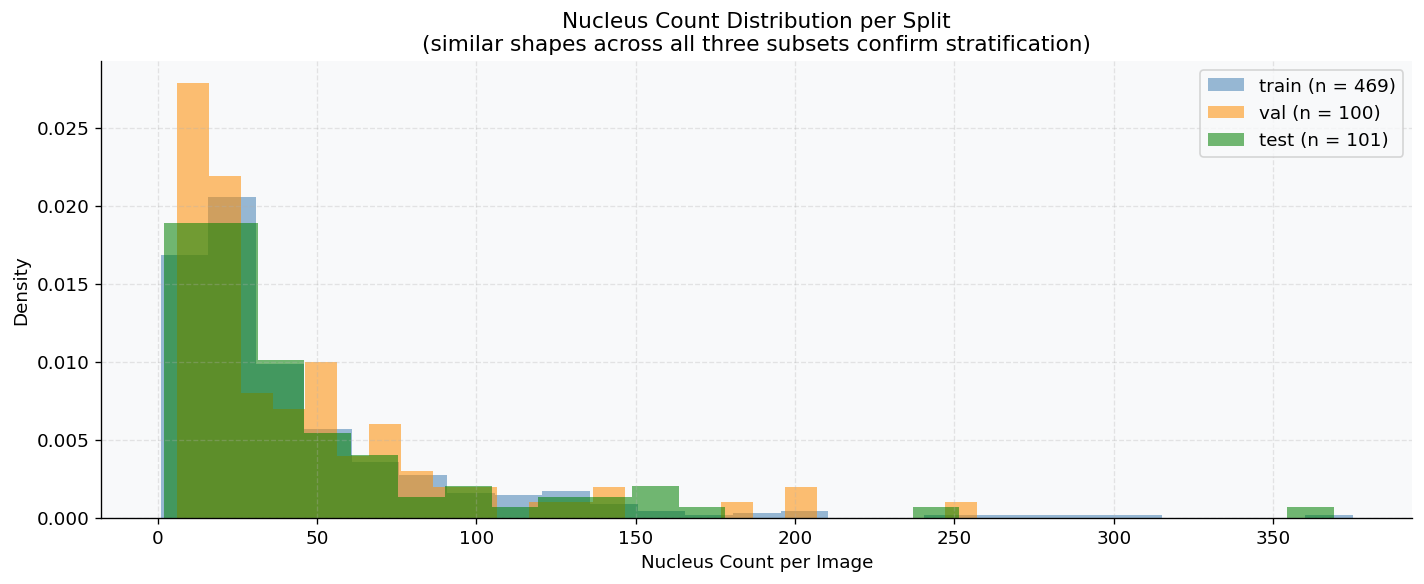

Saved: eda_split_distribution.png
  Saved: train_ids.txt  (469 sample IDs)
  Saved: val_ids.txt  (100 sample IDs)
  Saved: test_ids.txt  (101 sample IDs)

IMPORTANT: Downstream notebooks must load these files rather than
re-generating the split, to prevent data leakage between the
preprocessing and evaluation stages.


In [16]:
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# Stratified 70/15/15 split — bins by nucleus count quartile
# to balance easy/difficult images across train, val, and test.
df['nuclei_bin'] = pd.qcut(df['n_nuclei'], q=4, labels=False, duplicates='drop')

# Step 1: split train from the combined val+test pool.
train_ids, temp_ids = train_test_split(
    df['id'].tolist(),
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=SEED,
    stratify=df['nuclei_bin']
)

# Step 2: split val from test. Re-bin on the subset to avoid
# depleted strata in the reduced ~30% pool.
temp_df = df[df['id'].isin(temp_ids)].copy()
temp_df['nuclei_bin_local'] = pd.qcut(
    temp_df['n_nuclei'], q=4, labels=False, duplicates='drop'
)

# Verify that every local bin contains at least 2 samples before stratifying.
# If any bin is too small, fall back gracefully to an unstratified split
# rather than raising a ValueError at runtime.
bin_counts_local = temp_df['nuclei_bin_local'].value_counts()
if (bin_counts_local < 2).any():
    print('WARNING: Some local bins have fewer than 2 samples — '
          'falling back to unstratified split for val/test.')
    _strat_col = None
else:
    _strat_col = temp_df['nuclei_bin_local']

# test_size = TEST_RATIO / (VAL_RATIO + TEST_RATIO) = 0.50, splitting the
# temp pool equally into validation (15% of full dataset) and test
# (15% of full dataset).
val_ids, test_ids = train_test_split(
    temp_df['id'].tolist(),
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    random_state=SEED,
    stratify=_strat_col
)

# Annotate the master DataFrame with the assigned split for downstream plots.
df['split'] = 'train'
df.loc[df['id'].isin(val_ids),  'split'] = 'val'
df.loc[df['id'].isin(test_ids), 'split'] = 'test'

print('='*66)
print('                  DATASET SPLIT SUMMARY')
print('='*66)
for split_name in ['train', 'val', 'test']:
    sub = df[df['split'] == split_name]
    print(
        f'  {split_name.upper():<8}: {len(sub):>4} images ({len(sub)/len(df)*100:.1f}%)'
        f'  |  Nuclei mean = {sub["n_nuclei"].mean():.1f}'
        f'  |  Coverage mean = {sub["coverage_ratio"].mean()*100:.1f}%'
    )
print('='*66)
print('\nSimilar nuclei means and coverage means across all three subsets')
print('confirm that stratification is working correctly.')
print('Use the exact counts printed above in the report, not the')
print('approximate values stated in the markdown cell.')


# Visualise nucleus count distributions per split to provide a graphical
# confirmation that the three distributions overlap closely.
fig, ax = plt.subplots(figsize=(12, 5))
colors_split = {'train': 'steelblue', 'val': 'darkorange', 'test': 'green'}
for split_name, color in colors_split.items():
    sub = df[df['split'] == split_name]['n_nuclei']
    ax.hist(
        sub, bins=25, alpha=0.55, color=color,
        label=f'{split_name} (n = {len(sub)})',
        edgecolor='none', density=True
    )
ax.set_xlabel('Nucleus Count per Image')
ax.set_ylabel('Density')
ax.set_title(
    'Nucleus Count Distribution per Split\n'
    '(similar shapes across all three subsets confirm stratification)'
)
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}eda_split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_split_distribution.png')


# Persist split IDs to plain-text files — one sample ID per line.
# SPLITS_DIR is a top-level constant defined in the path-configuration cell.
# All downstream notebooks load these files to reconstruct the split rather
# than re-running train_test_split, which would alter the split composition
# if the random seed or dataset size changes and constitutes data leakage.
os.makedirs(SPLITS_DIR, exist_ok=True)

for split_name, ids in [('train', train_ids), ('val', val_ids), ('test', test_ids)]:
    out_path = os.path.join(SPLITS_DIR, f'{split_name}_ids.txt')
    with open(out_path, 'w') as f:
        f.write('\n'.join(ids))
    print(f'  Saved: {split_name}_ids.txt  ({len(ids)} sample IDs)')

print('\nIMPORTANT: Downstream notebooks must load these files rather than')
print('re-generating the split, to prevent data leakage between the')
print('preprocessing and evaluation stages.')


---
## 13. EDA Summary and Preprocessing Decisions

The table below maps each empirical finding from the EDA to a concrete preprocessing decision. These decisions are implemented in **Notebooks 02 (Preprocessing) and 03 (Augmentation)**.


In [17]:
# EDA findings-to-decisions mapping table.
# Every observation cell is constructed dynamically from variables computed
# during the scan and channel-analysis stages, so the table remains accurate
# regardless of which dataset subset is used.  No hardcoded numerical values
# appear in the Observation column.
#
# Dependencies (cells that must have executed before this cell):
#   scan cell     -> df, total_masks_checked, non_binary_count,
#                    empty_mask_count, size_mismatch_count, train_ids
#   channel cell  -> channel_freq, channel_map
#   path cell     -> _target_str
summary_data = {
    'Finding': [
        'Image sizes',
        'Channel type',
        'Pixel intensity range',
        'Nucleus count per image',
        'Class imbalance',
        'Mask quality',
        'Training set size',
    ],
    'Observation': [
        f'{len(set(zip(df.width, df.height)))} distinct sizes, {df.width.min()}-{df.width.max()} px wide',
        # channel_freq is defined in Section 6 (channel-analysis cell).
        # Guard: if Section 6 has not been run, show a clear fallback message
        # rather than raising a NameError that crashes the whole summary cell.
        (
            f'{(df.n_channels == channel_freq.idxmax()).sum()} images are '
            f'{channel_map.get(channel_freq.idxmax(), str(channel_freq.idxmax()))} '
            f'({channel_freq.max()/len(df)*100:.0f}% of dataset)'
            if 'channel_freq' in vars()
            else '[Run Section 6 first to populate this field]'
        ),
        f'Per-image mean ranges from {df.mean_intensity.min():.0f} to {df.mean_intensity.max():.0f} (grayscale)',
        f'Mean = {df.n_nuclei.mean():.0f}, median = {df.n_nuclei.median():.0f}, max = {df.n_nuclei.max()}',
        f'Foreground = {df.coverage_ratio.mean()*100:.1f}%, background = {100-df.coverage_ratio.mean()*100:.1f}%',
        f'{total_masks_checked} masks checked: {non_binary_count} non-binary, {empty_mask_count} empty, {size_mismatch_count} size mismatches',
        f'{len(train_ids)} training images (very small for deep learning)',
    ],
    'Preprocessing Decision': [
        # _target_str is defined in the path-configuration cell (Section 2)
        # as a top-level constant.
        f'Resize all images and masks to {_target_str} (bilinear / nearest-neighbour) — Notebook 02',
        'Convert all images to RGB via PIL .convert("RGB") — drops alpha channel — Notebook 02',
        'Divide by 255 → [0, 1] float32 — Notebook 02, normalise_image(). '
        'UNet trained from scratch; ImageNet mean/std not applied (not meaningful for microscopy).',
        'Merge all instance masks into one binary mask using np.maximum() — Notebook 02',
        'Use Dice Loss; evaluate with Dice coefficient and IoU (not pixel accuracy) — Notebook 03',
        'Apply threshold > 127 as a defensive binarisation step in preprocessing — Notebook 02',
        'Apply aggressive augmentation: flips, rotation, elastic deformation, colour jitter — Notebook 03',
    ]
}

summary_df = pd.DataFrame(summary_data)
pd.set_option('display.max_colwidth', 80)

print('EDA FINDINGS AND PREPROCESSING DECISIONS')
print('='*100)
display(summary_df)
print('\nAll decisions above are implemented in Notebooks 02 (Preprocessing) and 03 (Augmentation).')

EDA FINDINGS AND PREPROCESSING DECISIONS


,Finding,Observation,Preprocessing Decision
0,Image sizes,"9 distinct sizes, 256-1388 px wide",Resize all images and masks to 256x256 (bilinear / nearest-neighbour) — Note...
1,Channel type,670 images are RGBA (4ch) (100% of dataset),"Convert all images to RGB via PIL .convert(""RGB"") — drops alpha channel — No..."
2,Pixel intensity range,Per-image mean ranges from 1 to 218 (grayscale),"Divide by 255 → [0, 1] float32 — Notebook 02, normalise_image(). UNet traine..."
3,Nucleus count per image,"Mean = 44, median = 27, max = 375",Merge all instance masks into one binary mask using np.maximum() — Notebook 02
4,Class imbalance,"Foreground = 13.9%, background = 86.1%",Use Dice Loss; evaluate with Dice coefficient and IoU (not pixel accuracy) —...
5,Mask quality,"29461 masks checked: 0 non-binary, 0 empty, 0 size mismatches",Apply threshold > 127 as a defensive binarisation step in preprocessing — No...
6,Training set size,469 training images (very small for deep learning),"Apply aggressive augmentation: flips, rotation, elastic deformation, colour ..."



All decisions above are implemented in Notebooks 02 (Preprocessing) and 03 (Augmentation).


In [19]:
# Report all EDA figures written to the shared figures directory during this
# notebook.  The 'eda_' prefix filter ensures that figures produced by other
# notebooks (which share the same FIGURES_PATH) are not included in the count.
eda_figs = sorted([f for f in os.listdir(FIGURES_PATH)
                   if f.endswith('.png') and f.startswith('eda_')])
print('Figures generated by this notebook:')
for i, fname in enumerate(eda_figs, 1):
    print(f'  {i:>2}. {fname}')
print(f'\n  Total EDA figures: {len(eda_figs)}')

Figures generated by this notebook:
   1. eda_channel_types.png
   2. eda_instance_masks.png
   3. eda_intensity_analysis.png
   4. eda_mask_coverage.png
   5. eda_nucleus_counts.png
   6. eda_size_distribution.png
   7. eda_split_distribution.png
   8. eda_visual_samples.png

  Total EDA figures: 8
